<a href="https://colab.research.google.com/github/eliasdengo/Python-practice-from-beginning-to-advance/blob/Eliasrepos/covid19_Prediction_System_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

dependenc importance

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,r2_score
from sklearn.ensemble import RandomForestClassifier


data collection and processing

In [4]:
covid19_data = pd.read_csv('/content/sample_data/covid19_dataset_500.csv')

In [5]:
covid19_data.head()

,Breathing Problem,Fever,Dry Cough,Sore throat,Running Nose,Asthma,Chronic Lung Disease,Headache,Heart Disease,Diabetes,...,Fatigue,Gastrointestinal,Abroad travel,Contact with COVID Patient,Attended Large Gathering,Visited Public Exposed Places,Family working in Public Exposed Places,Wearing Masks,Sanitization from Market,COVID-19
0,1,1,1,0,0,0,0,1,0,0,...,1,0,1,0,1,1,0,1,1,1
1,0,1,1,1,0,0,0,0,0,0,...,0,0,0,1,0,1,1,1,0,1
2,1,0,0,0,1,1,0,1,0,0,...,1,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
4,1,1,0,0,0,0,1,1,1,1,...,1,1,1,1,1,1,1,0,0,1


In [6]:
covid19_data.tail()

,Breathing Problem,Fever,Dry Cough,Sore throat,Running Nose,Asthma,Chronic Lung Disease,Headache,Heart Disease,Diabetes,...,Fatigue,Gastrointestinal,Abroad travel,Contact with COVID Patient,Attended Large Gathering,Visited Public Exposed Places,Family working in Public Exposed Places,Wearing Masks,Sanitization from Market,COVID-19
254,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
255,1,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,1,0,0
256,0,1,1,0,0,0,0,1,0,0,...,1,0,0,1,0,1,0,1,1,1
257,1,1,0,0,0,0,0,1,0,0,...,1,0,1,0,1,1,0,1,1,1
258,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0


In [7]:
covid19_data.shape

(259, 21)

In [8]:
covid19_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259 entries, 0 to 258
Data columns (total 21 columns):
 #   Column                                   Non-Null Count  Dtype
---  ------                                   --------------  -----
 0   Breathing Problem                        259 non-null    int64
 1   Fever                                    259 non-null    int64
 2   Dry Cough                                259 non-null    int64
 3   Sore throat                              259 non-null    int64
 4   Running Nose                             259 non-null    int64
 5   Asthma                                   259 non-null    int64
 6   Chronic Lung Disease                     259 non-null    int64
 7   Headache                                 259 non-null    int64
 8   Heart Disease                            259 non-null    int64
 9   Diabetes                                 259 non-null    int64
 10  Hyper Tension                            259 non-null    int64
 11  Fatigu

In [9]:
covid19_data.isnull().sum()

,0
Breathing Problem,0
Fever,0
Dry Cough,0
Sore throat,0
Running Nose,0
Asthma,0
Chronic Lung Disease,0
Headache,0
Heart Disease,0
Diabetes,0


In [10]:
covid19_data.describe()

,Breathing Problem,Fever,Dry Cough,Sore throat,Running Nose,Asthma,Chronic Lung Disease,Headache,Heart Disease,Diabetes,...,Fatigue,Gastrointestinal,Abroad travel,Contact with COVID Patient,Attended Large Gathering,Visited Public Exposed Places,Family working in Public Exposed Places,Wearing Masks,Sanitization from Market,COVID-19
count,259.000000,259.000000,259.000000,259.000000,259.000000,259.000000,259.000000,259.000000,259.000000,259.000000,...,259.000000,259.000000,259.000000,259.000000,259.000000,259.000000,259.000000,259.000000,259.000000,259.000000
mean,0.498069,0.501931,0.382239,0.204633,0.081081,0.023166,0.069498,0.490347,0.123552,0.073359,...,0.490347,0.069498,0.250965,0.366795,0.262548,0.494208,0.127413,0.745174,0.629344,0.501931
std,0.500964,0.500964,0.486875,0.404214,0.273488,0.150722,0.254792,0.500875,0.329707,0.261230,...,0.500875,0.254792,0.434408,0.482863,0.440871,0.500934,0.334081,0.436607,0.483916,0.500964
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,1.000000,0.000000,0.500000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
# to know number of target that has covid or not
covid19_data['COVID-19'].value_counts()

,count
COVID-19,
1,130
0,129


<Axes: xlabel='Breathing Problem', ylabel='count'>

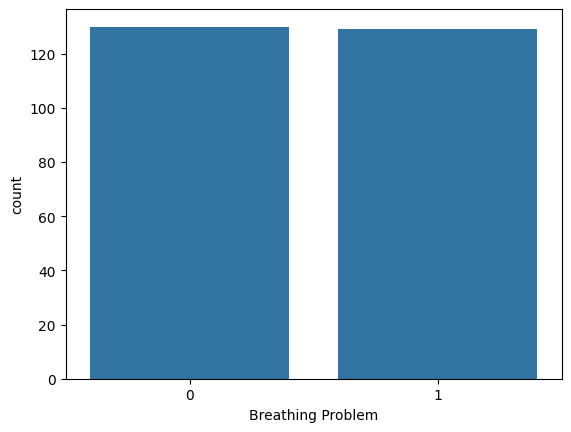

In [12]:
# to show breathing problem in histogram
sns.countplot(x='Breathing Problem', data=covid19_data)

<Axes: xlabel='Fever', ylabel='count'>

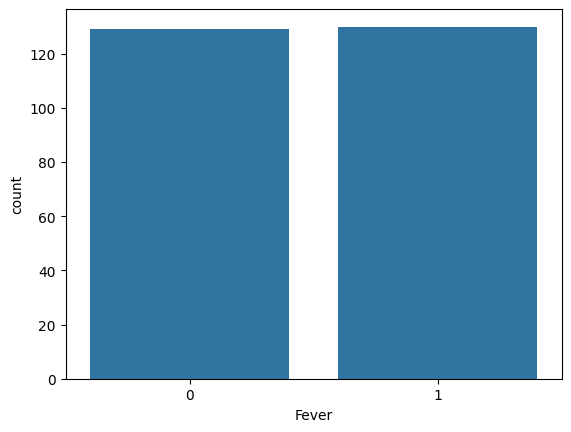

In [13]:
# for fever problem number
sns.countplot(x='Fever', data=covid19_data)


separate feature and target

In [14]:
x=covid19_data.drop(columns='COVID-19', axis=1)
y=covid19_data['COVID-19']

In [16]:
print(x)

     Breathing Problem  Fever  Dry Cough  Sore throat  Running Nose  Asthma  \
0                    1      1          1            0             0       0   
1                    0      1          1            1             0       0   
2                    1      0          0            0             1       1   
3                    0      0          0            0             0       0   
4                    1      1          0            0             0       0   
..                 ...    ...        ...          ...           ...     ...   
254                  0      0          0            0             0       0   
255                  1      0          0            0             0       0   
256                  0      1          1            0             0       0   
257                  1      1          0            0             0       0   
258                  0      0          0            0             0       0   

     Chronic Lung Disease  Headache  Heart Disease 

In [15]:
print(y)

0      1
1      1
2      0
3      0
4      1
      ..
254    0
255    0
256    1
257    1
258    0
Name: COVID-19, Length: 259, dtype: int64


spliting data into test and train data

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,stratify=y, random_state=2)

In [22]:
x.shape, x_train.shape, x_test.shape

((259, 20), (207, 20), (52, 20))

Training machine learning model

In [37]:
model=RandomForestClassifier( n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42)

In [38]:
model.fit(x_train, y_train)

RandomForestClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

model evaluation

In [39]:
x_covid19_train_prediction = model.predict(x_train)
training_data_r2 = r2_score(y_train, x_covid19_train_prediction)
print(f"Training R² score: {training_data_r2}")

Training R² score: 1.0


covid19 predicition system

In [40]:
input_data = (0,1,1,1,0,0,0,0,0,0,0,0,0,0,1,0,1,1,1,0)
input_data_as_array=np.asarray(input_data)
input_data_reshaped = input_data_as_array.reshape(1,-1)


In [41]:
pridiction = model.predict(input_data_reshaped)
print(pridiction)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
